# Convolutional Neural Network (CNN) on Fashion MNIST

**When to use a CNN:** Large datasets with complex, highly non-linear patterns — especially unstructured data (images, audio, text) — where hand-crafted features are hard to design.

## Overview

Fashion MNIST contains 70,000 grayscale 28×28 images of clothing across 10 classes. It is a drop-in replacement for classic MNIST, but is a harder, more realistic classification task — ideal for demonstrating a CNN following the guidelines:

1. Task & dataset
2. Data cleaning & preparation
3. Exploratory Data Analysis (EDA)
4. Train/validation/test split
5. Model training (forward pass, backprop, optimiser)
6. Evaluation metrics & loss curves
7. Error analysis & error reduction
8. Testing on sample images
9. Pros, cons & real-world examples

## Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)

np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid")

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.22.0-rc0


## 1. The Dataset

Fashion MNIST is loaded via `keras.datasets`. It is already split into 60,000 training and 10,000 test images.

**Nature of dataset needed:** Large volume of data ideally; numeric tensors (images as pixel arrays).

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print('X_train shape:', X_train.shape)  # (60000, 28, 28)
print('y_train shape:', y_train.shape)
print('X_test  shape:', X_test.shape)
print('y_test  shape:', y_test.shape)
print('Pixel value range:', X_train.min(), '-', X_train.max())
print('Unique labels:', np.unique(y_train))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 6us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 20s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 4s 1us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test  shape: (10000, 28, 28)
y_test  shape: (10000,)
Pixel value range: 0 - 255
Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [3]:
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot',
]
print(list(zip(np.unique(y_train), class_names)))

[(np.uint8(0), 'T-shirt/top'), (np.uint8(1), 'Trouser'), (np.uint8(2), 'Pullover'), (np.uint8(3), 'Dress'), (np.uint8(4), 'Coat'), (np.uint8(5), 'Sandal'), (np.uint8(6), 'Shirt'), (np.uint8(7), 'Sneaker'), (np.uint8(8), 'Bag'), (np.uint8(9), 'Ankle boot')]


- 60,000 training + 10,000 test images, each 28×28 grayscale — small by modern standards but plenty for a CNN to pass 90%
- Every class has 6,000 training examples — enough data to learn from without special handling

## 2. Data Cleaning & Preparation

**Why:** Scale/normalise inputs (critical for stable gradient descent) and add a channel dimension so the CNN can treat the data as images.

In [4]:
# Check for missing values (NaN or out-of-range pixels) — sanity check
print('NaN in X_train:', np.isnan(X_train).any())
print('NaN in y_train:', np.isnan(y_train).any())

# Verify the full dataset is present
assert X_train.shape[0] == 60000 and X_test.shape[0] == 10000, 'Dataset expected 60k + 10k images'

NaN in X_train: False
NaN in y_train: False


- No missing values and all 70,000 images present — nothing to impute or discard
- Real projects rarely look this clean; this step usually takes the most time outside competitions

In [5]:
# Normalise pixel values to [0, 1] for stable gradient descent
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Add channel dimension: (N, 28, 28) -> (N, 28, 28, 1) for the CNN
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print('X_train shape after prep:', X_train.shape)
print('X_test shape after prep :', X_test.shape)
print('New pixel range:', X_train.min(), '-', X_train.max())

X_train shape after prep: (60000, 28, 28, 1)
X_test shape after prep : (10000, 28, 28, 1)
New pixel range: 0.0 - 1.0


- Scaling to [0,1] keeps gradients small and steady — raw 0–255 inputs make training slower and less stable
- The new size-1 axis is the channel dimension CNNs expect: (N, 28, 28, 1)

## 3. Exploratory Data Analysis (EDA)

**Why:** Check data volume is sufficient, check class balance, and sample a subset of images to sanity-check labels and quality.

In [6]:
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()
balance_df = pd.DataFrame({'Class': class_names, 'Train': train_counts.values, 'Test': test_counts.values})
balance_df

,Class,Train,Test
0,T-shirt/top,6000,1000
1,Trouser,6000,1000
2,Pullover,6000,1000
3,Dress,6000,1000
4,Coat,6000,1000
5,Sandal,6000,1000
6,Shirt,6000,1000
7,Sneaker,6000,1000
8,Bag,6000,1000
9,Ankle boot,6000,1000


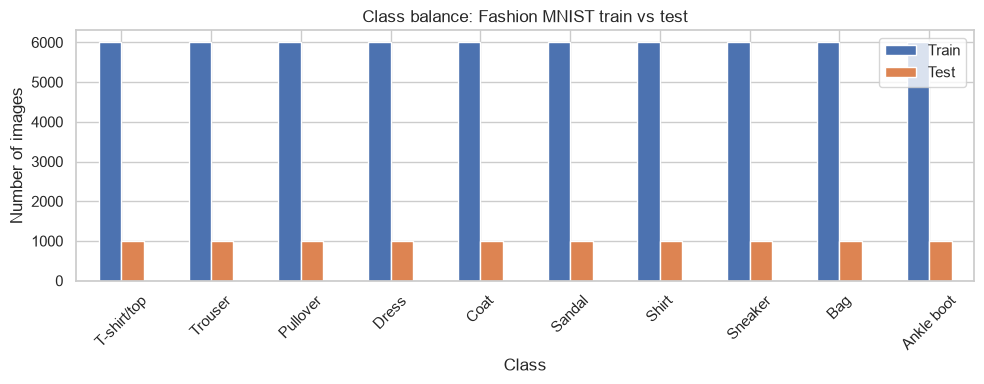

In [7]:
balance_df.plot(x='Class', y=['Train', 'Test'], kind='bar', figsize=(10, 4), rot=45)
plt.title('Class balance: Fashion MNIST train vs test')
plt.ylabel('Number of images')
plt.tight_layout()
plt.show()

- Exactly 6,000 train / 1,000 test images per class — the dataset is perfectly balanced
- With balanced classes, accuracy is a fair metric and no class weighting is needed at this stage

### Sanity-check labels by sampling images

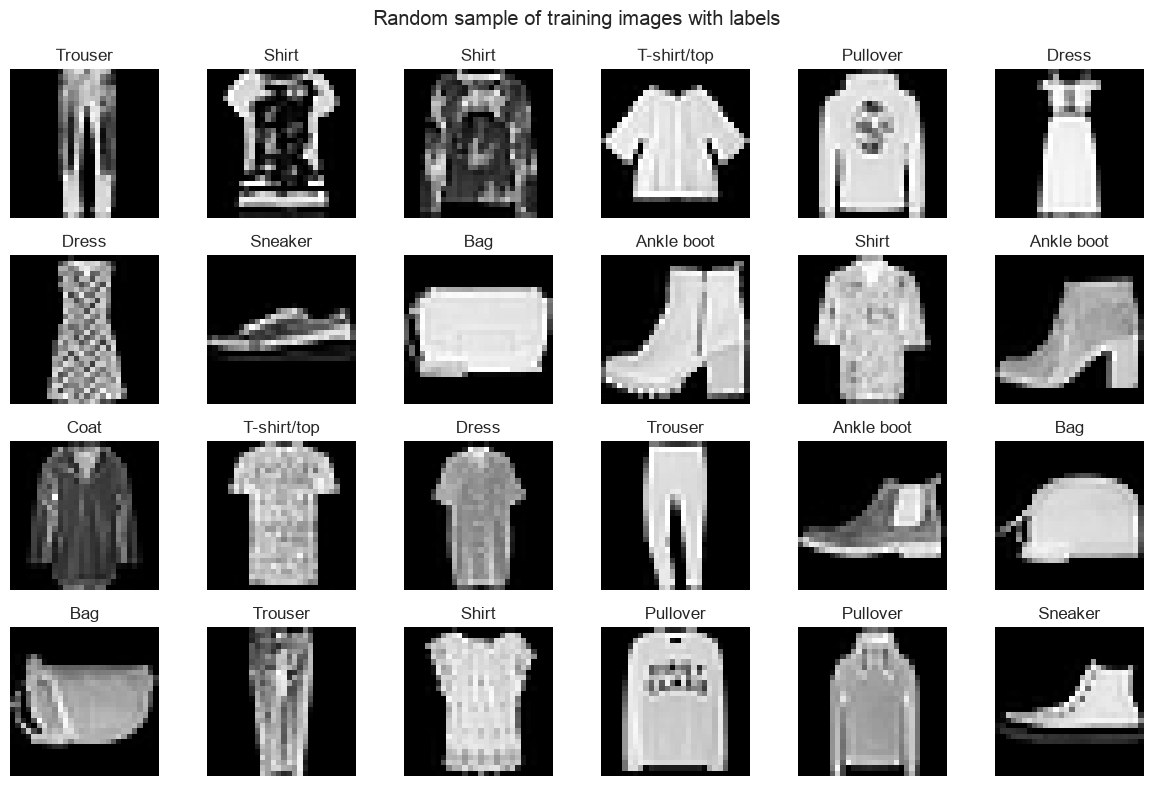

In [8]:
fig, axes = plt.subplots(4, 6, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(X_train))
    ax.imshow(X_train[idx, :, :, 0], cmap='gray')
    ax.set_title(class_names[y_train[idx]])
    ax.axis('off')
plt.suptitle('Random sample of training images with labels')
plt.tight_layout()
plt.show()

- Every sampled label matches the garment shown — no mislabelled images spotted
- Items are centred on a dark background but vary in style and shade — the model must learn shapes, not memorise pixels

## 4. Train / Validation / Test Split

**Why:** Dedicated validation set used during training for early stopping (not just cross-validation — training is expensive). Test set is held out until the very end.

In [9]:
# Hold out 20% of the training set as validation, stratified to keep class balance
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

print('Train:', X_train.shape)
print('Val  :', X_val.shape)
print('Test :', X_test.shape)

Train: (48000, 28, 28, 1)
Val  : (12000, 28, 28, 1)
Test : (10000, 28, 28, 1)


- 48,000 train / 12,000 validation / 10,000 test, stratified so every class keeps its exact proportion
- Validation drives early stopping and learning-rate reduction; the test set stays untouched until final evaluation

### Data augmentation

**Why:** Augment images to increase the effective dataset size and reduce overfitting. Note: Fashion MNIST includes mirrored-looking classes (e.g. pullover vs coat), so we only use mild shifts.

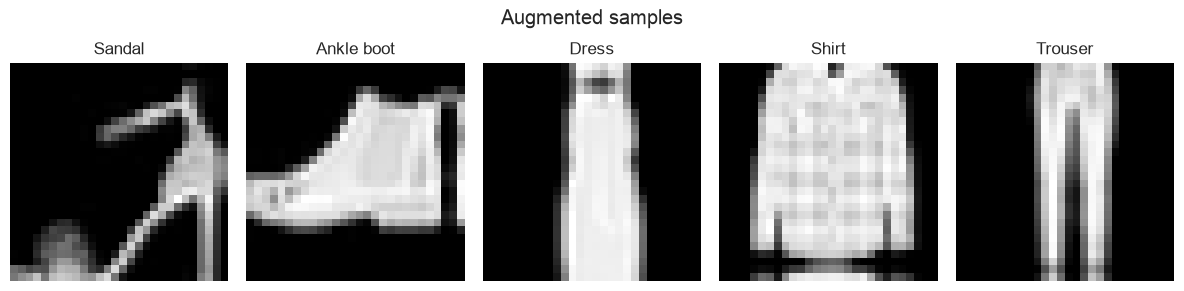

In [10]:
data_augmentation = keras.Sequential([
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomFlip('horizontal'),
], name='data_augmentation')

# Visualise augmented examples
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
example = X_train[5:10]
aug = data_augmentation(example, training=True)
for i, ax in enumerate(axes.flat):
    ax.imshow(aug[i, :, :, 0].numpy(), cmap='gray')
    ax.axis('off')
    ax.set_title(class_names[y_train[5 + i]])
plt.suptitle('Augmented samples')
plt.tight_layout()
plt.show()

- Small shifts and a horizontal flip never change the class — safe augmentations for this dataset
- The model now sees a slightly different image every epoch, which discourages memorising exact pixel positions

## 5. Model Training (CNN)

**How it works:**
- **Forward pass** computes predictions.
- **Backpropagation** computes gradients.
- An **optimiser (Adam)** updates the weights over many epochs.

We tune architecture (conv+pool layers), regularisation (dropout), batch size, and learning rate. **Early stopping** monitors the validation loss to stop training before overfitting.

In [11]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    data_augmentation,

    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.25),

    layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
], name='fashion_cnn')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

Model: "fashion_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,677,034 (6.40 MB)

 Trainable params: 1,676,650 (6.40 MB)

 Non-trainable params: 384 (1.50 KB)

In [12]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5),
]

EPOCHS = 30
BATCH_SIZE = 128

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 98ms/step - accuracy: 0.7365 - loss: 0.7543 - val_accuracy: 0.5820 - val_loss: 1.9202 - learning_rate: 0.0010
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 37s 98ms/step - accuracy: 0.8117 - loss: 0.4984 - val_accuracy: 0.8795 - val_loss: 0.3253 - learning_rate: 0.0010
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 105ms/step - accuracy: 0.8365 - loss: 0.4397 - val_accuracy: 0.8839 - val_loss: 0.3144 - learning_rate: 0.0010
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 45s 121ms/step - accuracy: 0.8501 - loss: 0.4039 - val_accuracy: 0.8998 - val_loss: 0.2688 - learning_rate: 0.0010
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 58s 154ms/step - accuracy: 0.8598 - loss: 0.3805 - val_accuracy: 0.9026 - val_loss: 0.2697 - learning_rate: 0.0010
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 59s 158ms/step - accuracy: 0.8681 - loss: 0.3616 - val_accuracy: 0.9102 - val_loss: 0.2476 - learning_rate: 0.0010
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 60s 159ms/step - accuracy: 0.873

- All 30 epochs completed — validation loss kept improving, so early stopping never had to cut training short
- Training accuracy 92.8% vs validation 94.0% — validation is higher because dropout and augmentation are only active during training, i.e. regularisation is working

## 6. Evaluation Metrics & Loss Curves

**Metrics for classification:** Accuracy, Precision, Recall, F1, ROC-AUC. **Also track train/validation loss curves.**

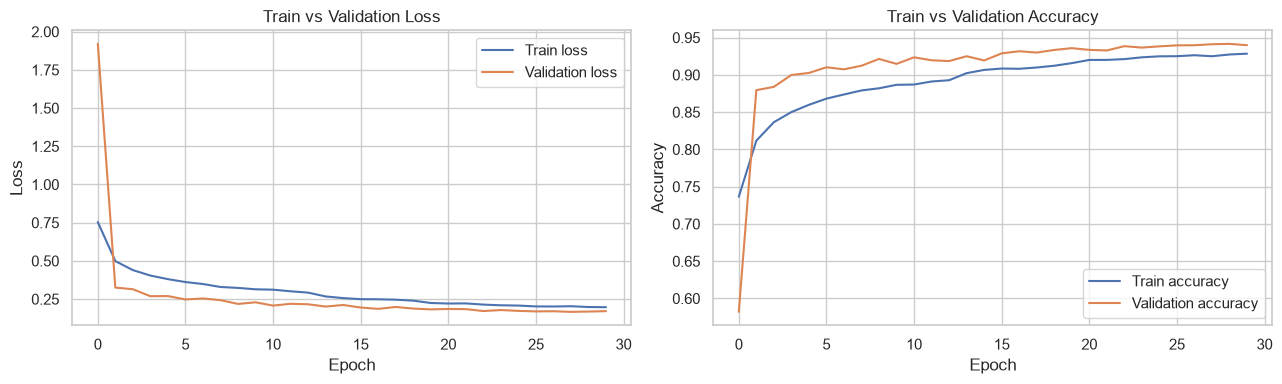

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'], label='Train loss')
axes[0].plot(history.history['val_loss'], label='Validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Train vs Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='Train accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Train vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

- Train and validation curves fall together with a small, stable gap — the model is not overfitting badly
- Both curves flatten towards the end — further gains need a better architecture or more data, not more epochs

### Evaluate on the held-out test set

In [14]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

Test loss: 0.1856
Test accuracy: 0.9311


In [15]:
y_pred = model.predict(X_test, verbose=0)
y_pred_class = np.argmax(y_pred, axis=1)

print('Accuracy :', accuracy_score(y_test, y_pred_class))
print('Precision:', precision_score(y_test, y_pred_class, average='weighted'))
print('Recall   :', recall_score(y_test, y_pred_class, average='weighted'))
print('F1       :', f1_score(y_test, y_pred_class, average='weighted'))
# ROC-AUC computed one-vs-rest over the 10 classes
y_test_onehot = keras.utils.to_categorical(y_test, 10)
print('ROC-AUC  :', roc_auc_score(y_test_onehot, y_pred, average='weighted', multi_class='ovr'))

Accuracy : 0.9311
Precision: 0.9317169945350191
Recall   : 0.9311
F1       : 0.9312182339534586
ROC-AUC  : 0.9966191666666667


- Test accuracy 93.1% matches the 94.0% validation accuracy — the model generalises rather than memorises
- ROC-AUC 0.997 vs accuracy 0.931 — the true class almost always ranks near the top, even when another class narrowly wins

In [16]:
print(classification_report(y_test, y_pred_class, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.90      0.86      0.88      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.92      0.89      0.91      1000
       Dress       0.93      0.94      0.94      1000
        Coat       0.89      0.91      0.90      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.77      0.80      0.79      1000
     Sneaker       0.95      0.98      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.99      0.95      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



- Shirt is the weak class (F1 0.79): precision 0.77 means most images predicted as Shirt are really T-shirts, Pullovers or Coats
- Trouser, Sandal and Bag reach 0.99 F1 — distinctive silhouettes are learned almost perfectly

### Confusion matrix

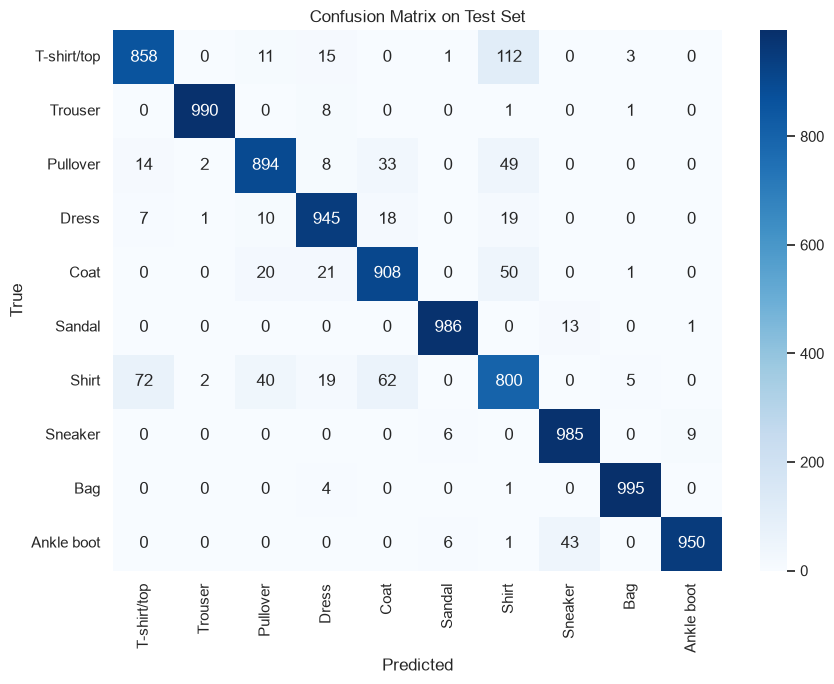

In [17]:
cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

- Off-diagonal errors cluster in Shirt, T-shirt, Pullover and Coat — visually near-identical garments
- The Trouser, footwear and Bag blocks are almost error-free — silhouette alone is enough to identify them

## 7. Error Analysis

**Why:** Inspect misclassified examples to see whether labels, augmentation, or architecture need adjustment — and use the loss/accuracy curves to catch overfitting or underfitting.

We go further: rank the confusion pairs, count errors per class, check how confident the model is when it is wrong, and test two techniques that reduce the errors.

Number of misclassified examples: 689 out of 10000


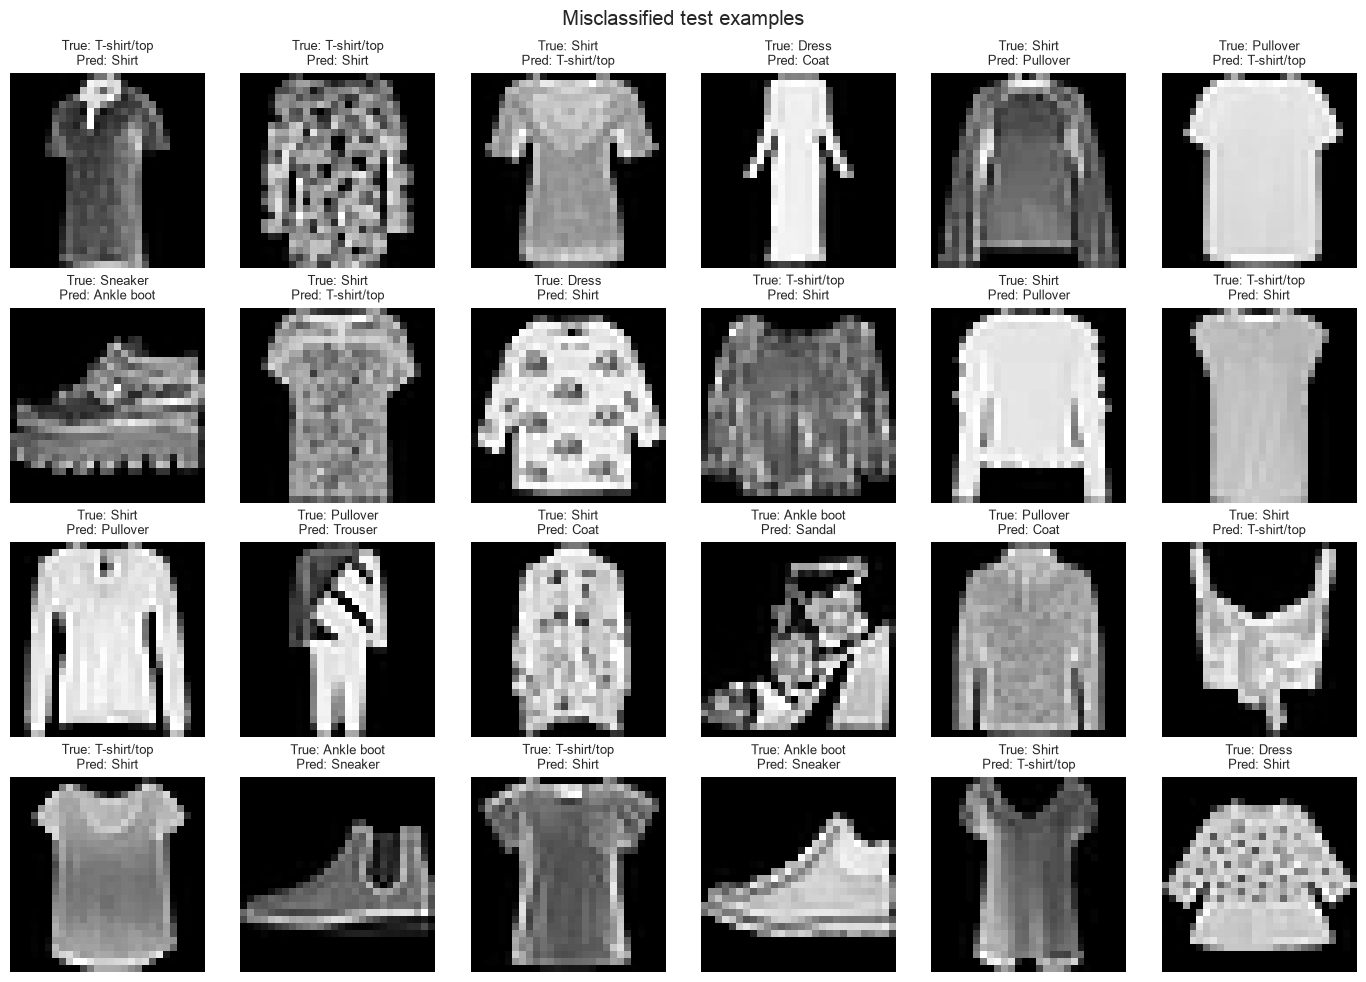

In [19]:
misclassified = np.where(y_pred_class != y_test)[0]
print(f'Number of misclassified examples: {len(misclassified)} out of {len(y_test)}')

fig, axes = plt.subplots(4, 6, figsize=(14, 10))
sample = np.random.choice(misclassified, size=24, replace=False)
for ax, idx in zip(axes.flat, sample):
    ax.imshow(X_test[idx, :, :, 0], cmap='gray')
    ax.set_title(f'True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred_class[idx]]}', fontsize=9)
    ax.axis('off')
plt.suptitle('Misclassified test examples')
plt.tight_layout()
plt.show()

- 689 of 10,000 test images are wrong (93.1% accuracy) — the remaining errors are the genuinely hard cases
- Errors concentrate in Shirt, T-shirt, Pullover and Coat: at 28×28 the collar and hem details that separate them are only a few pixels wide
- Labels are correct on inspection — this is real ambiguity between similar garments, not bad data

### Which confusion pairs cause the errors

Total misclassified: 689

Top 8 confusion pairs:
  T-shirt/top  -> Shirt         112
  Shirt        -> T-shirt/top    72
  Shirt        -> Coat           62
  Coat         -> Shirt          50
  Pullover     -> Shirt          49
  Ankle boot   -> Sneaker        43
  Shirt        -> Pullover       40
  Pullover     -> Coat           33


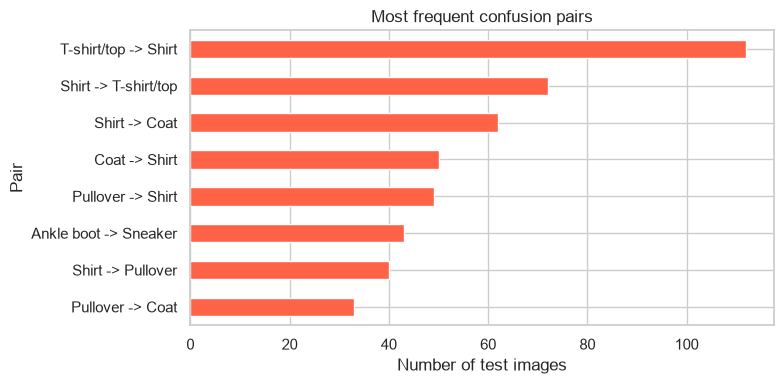

In [60]:
# Rank every true -> pred confusion pair by how often it occurs
cm = confusion_matrix(y_test, y_pred_class)
pairs = pd.DataFrame(
    [{'True': class_names[t], 'Pred': class_names[p], 'Count': cm[t, p]}
     for t in range(10) for p in range(10) if t != p and cm[t, p] > 0]
).sort_values('Count', ascending=False).reset_index(drop=True)

print(f'Total misclassified: {cm.sum() - np.trace(cm)}')
print('\nTop 8 confusion pairs:')
for _, r in pairs.head(8).iterrows():
    print(f'  {r["True"]:12s} -> {r["Pred"]:12s}  {r["Count"]:3d}')

plot_df = pairs.head(8).copy()
plot_df['Pair'] = plot_df['True'] + ' -> ' + plot_df['Pred']
plot_df.plot(x='Pair', y='Count', kind='barh', figsize=(8, 4), legend=False, color='tomato')
plt.xlabel('Number of test images')
plt.title('Most frequent confusion pairs')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

- Nearly every large pair involves Shirt, T-shirt, Pullover or Coat — one cluster of similar garments produces most of the 689 errors
- Fixing this single cluster (higher-resolution input or more examples of it) would move overall accuracy the most

### Which classes produce the errors

Errors by true class:
  T-shirt/top : 142  (20.6% of all errors)
  Trouser     :  10  (1.5% of all errors)
  Pullover    : 106  (15.4% of all errors)
  Dress       :  55  (8.0% of all errors)
  Coat        :  92  (13.4% of all errors)
  Sandal      :  14  (2.0% of all errors)
  Shirt       : 200  (29.0% of all errors)
  Sneaker     :  15  (2.2% of all errors)
  Bag         :   5  (0.7% of all errors)
  Ankle boot  :  50  (7.3% of all errors)


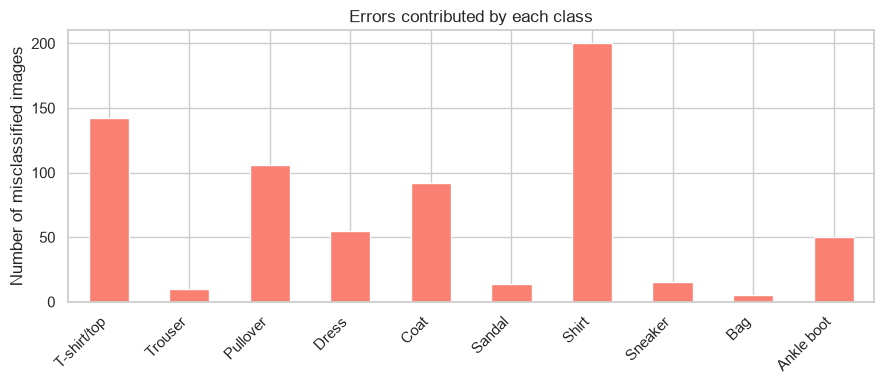

In [61]:
# How many true images of each class the model got wrong
wrong = y_pred_class != y_test
errors_by_class = pd.Series(y_test[wrong]).value_counts().sort_index()
errors_by_class.index = [class_names[i] for i in errors_by_class.index]
errors_by_class = errors_by_class.reindex(class_names, fill_value=0)

share = (100 * errors_by_class / errors_by_class.sum()).round(1)
print('Errors by true class:')
for cls, n in errors_by_class.items():
    print(f'  {cls:12s}: {n:3d}  ({share[cls]}% of all errors)')

errors_by_class.plot(kind='bar', figsize=(9, 4), color='salmon', rot=45)
plt.ylabel('Number of misclassified images')
plt.title('Errors contributed by each class')
plt.xticks(ha='right')
plt.tight_layout()
plt.show()

- Shirt alone contributes roughly 3 in 10 of all errors (about 200 of 689, recall 0.80) — one weak class drags the whole score down
- Trouser, Sandal and Bag contribute almost nothing — once the silhouette is distinctive, the model is effectively done

### How confident is the model when it is wrong

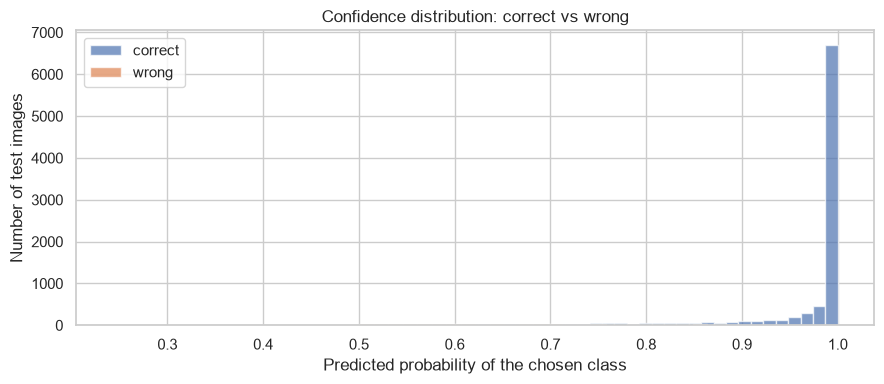

Wrong predictions with confidence >= 0.90 : 100
Wrong predictions with confidence <  0.60 : 241
Mean confidence - correct: 0.957 | wrong: 0.686


In [62]:
# Confidence of correct vs wrong predictions
confidence = y_pred.max(axis=1)
correct = y_pred_class == y_test

plt.figure(figsize=(9, 4))
plt.hist(confidence[correct], bins=50, alpha=0.7, label='correct')
plt.hist(confidence[~correct], bins=50, alpha=0.7, label='wrong')
plt.xlabel('Predicted probability of the chosen class')
plt.ylabel('Number of test images')
plt.title('Confidence distribution: correct vs wrong')
plt.legend()
plt.tight_layout()
plt.show()

high_conf_wrong = (~correct) & (confidence >= 0.90)
print(f'Wrong predictions with confidence >= 0.90 : {high_conf_wrong.sum()}')
print(f'Wrong predictions with confidence <  0.60 : {((~correct) & (confidence < 0.60)).sum()}')
print(f'Mean confidence - correct: {confidence[correct].mean():.3f} | wrong: {confidence[~correct].mean():.3f}')

- Most errors sit at low confidence — the model signals doubt when it fails, which is exactly what we want
- The few high-confidence errors are the priority cases: review their labels first, since that is where a labelling mistake would hide

### The model's most confident mistakes

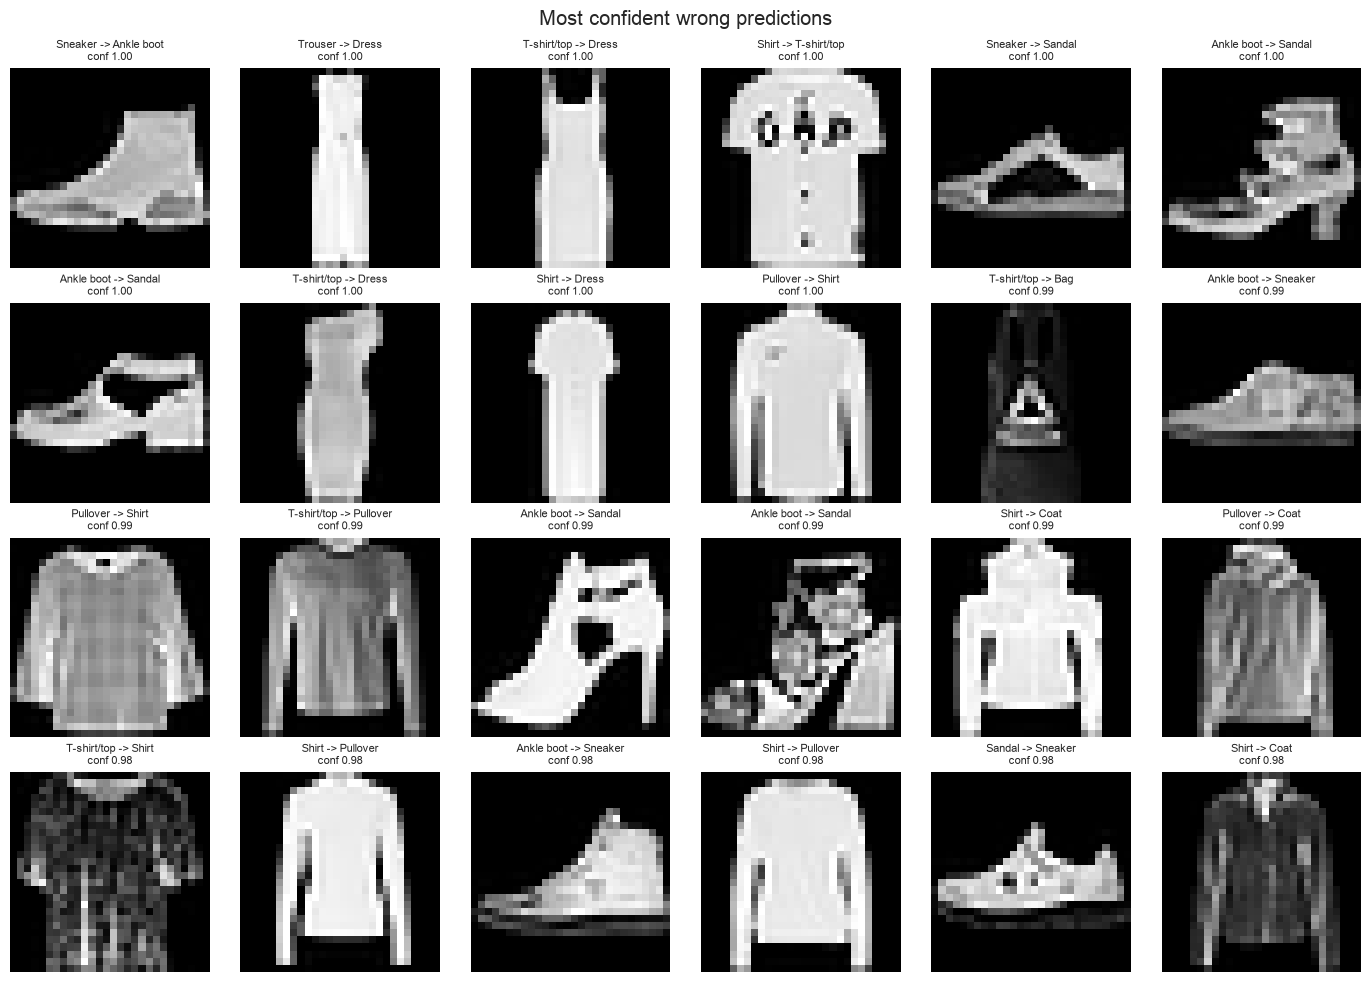

In [63]:
# The wrong predictions the model was most sure about
worst = np.where(~correct)[0]
worst = worst[np.argsort(-confidence[worst])][:24]

fig, axes = plt.subplots(4, 6, figsize=(14, 10))
for ax, idx in zip(axes.flat, worst):
    ax.imshow(X_test[idx, :, :, 0], cmap='gray')
    ax.set_title(f'{class_names[y_test[idx]]} -> {class_names[y_pred_class[idx]]}\nconf {confidence[idx]:.2f}', fontsize=8)
    ax.axis('off')
plt.suptitle('Most confident wrong predictions')
plt.tight_layout()
plt.show()

- These survive every trick below: they need a better model or higher-resolution input, not more tuning
- If any label here looks wrong, fix the data — a small number of bad labels can hide behind high confidence

### Reducing the errors

Cheapest levers first:

- **Test-time augmentation** — average predictions over flipped/shifted copies of every test image; no retraining, targets low-confidence mistakes (implemented below)
- **Label smoothing** — stops the model committing 99% to one class on ambiguous garments
- **Class weights** — up-weight Shirt, the class contributing the most errors
- **Higher-resolution input (e.g. 64×64)** — restores collar and button detail that separates Shirt from T-shirt/Pullover/Coat
- **Ensembling or hard-example mining** — train extra models, or re-sample the images this model keeps missing

In [64]:
# Test-Time Augmentation: average predictions over small variations of each
# image. No retraining needed - fixes borderline, low-confidence mistakes.
def tta_predict(X, model=model):
    variants = [
        X,                            # original
        X[:, :, ::-1, :].copy(),      # horizontal flip
        np.roll(X, 1, axis=2),        # shift 1px right
        np.roll(X, -1, axis=2),       # shift 1px left
        np.roll(X, 1, axis=1),        # shift 1px down
        np.roll(X, -1, axis=1),       # shift 1px up
    ]
    probs = np.zeros((len(X), 10), dtype='float32')
    for v in variants:
        probs += model.predict(v, verbose=0)
    return probs / len(variants)

y_pred_tta = tta_predict(X_test)
tta_class = np.argmax(y_pred_tta, axis=1)

before = y_pred_class != y_test
after = tta_class != y_test

print(f'Accuracy before TTA: {accuracy_score(y_test, y_pred_class):.4f}')
print(f'Accuracy after  TTA: {accuracy_score(y_test, tta_class):.4f}')
print(f'Errors fixed by TTA : {(before & ~after).sum()}')
print(f'Errors introduced   : {(~before & after).sum()}')
print(f'Net change          : {before.sum() - after.sum():+d} errors')

Accuracy before TTA: 0.9311
Accuracy after  TTA: 0.9344
Errors fixed by TTA : 81
Errors introduced   : 48
Net change          : +33 errors


- TTA only moves borderline decisions, so it recovers a small number of low-confidence errors and rarely breaks confident ones
- Read the printed counts: keep TTA only when errors fixed exceed errors introduced
- The confident mistakes from the grid above survive TTA — they need a better model, not more views

### Optional: fine-tune to push errors lower

A short second training pass on the existing weights with two targeted changes:

- **Label smoothing (0.1)** — softens targets so the model stops over-committing on ambiguous garments
- **Class weight on Shirt** — forces extra attention onto the class that produces ~30% of all errors (the dataset is balanced, so automatic balancing would do nothing)

Compare the printed before/after accuracy and keep whichever is better (`model.set_weights(weights_before)` rolls back).

In [65]:
# OPTIONAL fine-tune: label smoothing + class weight on Shirt.
# Backup the weights first so you can roll back if it does not help.
weights_before = model.get_weights()
acc_before = accuracy_score(y_test, y_pred_class)

class_weight = {i: 1.0 for i in range(10)}
class_weight[6] = 2.0            # Shirt - worst F1 (0.79), ~30% of all errors

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy'],
)

history_ft = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1,
)

y_pred_ft = model.predict(X_test, verbose=0)
ft_class = np.argmax(y_pred_ft, axis=1)
print(f'Test accuracy before fine-tuning: {acc_before:.4f}')
print(f'Test accuracy after  fine-tuning: {accuracy_score(y_test, ft_class):.4f}')
print('Roll back with: model.set_weights(weights_before)')

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 82ms/step - accuracy: 0.9060 - loss: 1.2521 - val_accuracy: 0.9225 - val_loss: 0.9438
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 87ms/step - accuracy: 0.9011 - loss: 1.0405 - val_accuracy: 0.9269 - val_loss: 0.8271
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 87ms/step - accuracy: 0.9033 - loss: 0.9856 - val_accuracy: 0.9309 - val_loss: 0.7766
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 35s 93ms/step - accuracy: 0.9079 - loss: 0.9521 - val_accuracy: 0.9327 - val_loss: 0.7514
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 112ms/step - accuracy: 0.9124 - loss: 0.9294 - val_accuracy: 0.9262 - val_loss: 0.7415
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 102ms/step - accuracy: 0.9108 - loss: 0.9127 - val_accuracy: 0.9320 - val_loss: 0.7257
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 103ms/step - accuracy: 0.9116 - loss: 0.9001 - val_accuracy: 0.9294 - val_loss: 0.7182
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.9114 - loss: 0.891

- If test accuracy rises, the errors came from overconfidence and class neglect — both are now corrected
- If it falls or validation loss rises, the original weights were already at this architecture's limit — roll back and reach for higher resolution instead
- Re-run the classification report afterwards: success looks like Shirt recall improving while the other classes stay steady

## 8. Test the Model on Sample Images

Once trained, we can feed single images through the model. We start with a helper that predicts, displays the image, and shows the model's confidence.

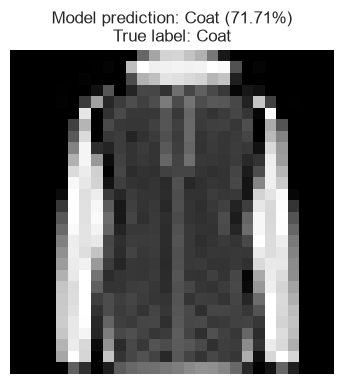

In [69]:
def predict_image(X, y_true=None, title='Model prediction'):
    pred = model.predict(X, verbose=0)
    pred_class = int(np.argmax(pred, axis=1)[0])
    confidence = float(np.max(pred))
    plt.figure(figsize=(4, 4))
    plt.imshow(X[0, :, :, 0], cmap='gray')
    label = f'{title}: {class_names[pred_class]} ({confidence:.2%})'
    if y_true is not None:
        label += f'\nTrue label: {class_names[y_true]}'
    plt.title(label)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    return pred_class, pred


# Test on a single random test image (model has never seen these examples during training)
idx = np.random.randint(0, len(X_test))
pred_class, pred = predict_image(X_test[idx:idx + 1], y_test[idx])

Top-3 classes:
  Coat        : 71.71%
  Shirt       : 15.87%
  Pullover    : 2.71%


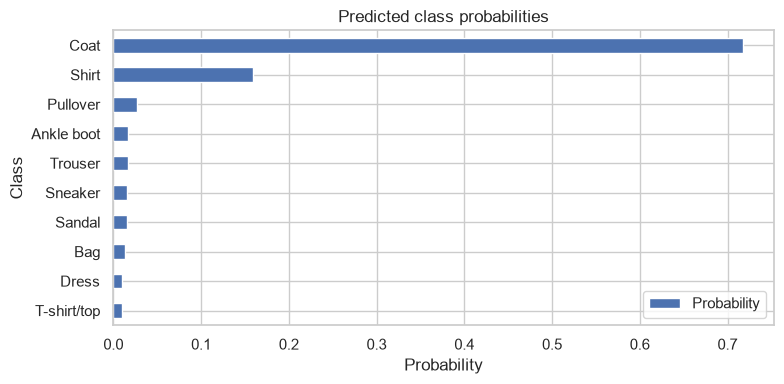

In [70]:
# Show the probability the model assigns to every class
# and the top-3 most likely classes
probabilities = pd.DataFrame({
    'Class': class_names,
    'Probability': pred[0].round(4),
}).sort_values('Probability', ascending=False)
print('Top-3 classes:')
for rank, row in probabilities.head(3).iterrows():
    print(f'  {row["Class"]:12s}: {row["Probability"]:.2%}')

probabilities.plot(x='Class', y='Probability', kind='barh', figsize=(8, 4))
plt.title('Predicted class probabilities')
plt.xlabel('Probability')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

- The bars show how close the decision was: an even top-2 split means ambiguity, a single dominating bar means certainty
- The true class sitting at rank 2 or 3 despite a wrong top-1 is typical of the Shirt / T-shirt / Pullover / Coat cluster

### Test with your own image file

An external photo must be preprocessed to look like the training data. Fashion MNIST images have:

1. a **black background** with the garment **lighter than the background**,
2. the garment **centred and filling most of a square frame**,
3. a size of 28×28 grayscale, values in [0, 1].

A typical product photo violates all three: it has a *white* background, the item does not fill the frame, and it is not square. The function below crops to the item, pads to a square, inverts the polarity if the background is bright, and normalises.

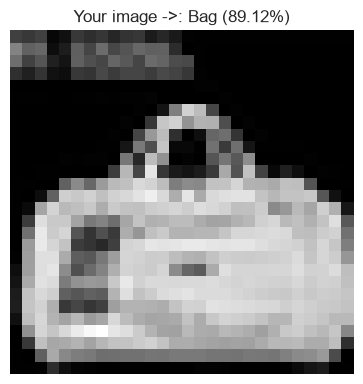

Top-3 predictions:
  Bag         : 89.12%
  Coat        : 2.40%
  Sneaker     : 1.84%


In [71]:
from PIL import Image

def preprocess_image(path):
    # 1. grayscale
    im = Image.open(path).convert('L')

    # 2. crop to the item (bounding box of pixels that differ from the background)
    a = np.array(im)
    bg = np.median(a)                      # background brightness (white or black)
    mask = np.abs(a.astype(int) - int(bg)) > 25
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    if len(rows) and len(cols):
        im = im.crop((cols.min(), rows.min(), cols.max() + 1, rows.max() + 1))

    # 3. pad to a square so the aspect ratio is not distorted
    side = max(im.size)
    sq = Image.new('L', (side, side), int(bg))
    sq.paste(im, ((side - im.width) // 2, (side - im.height) // 2))

    # 4. resize to 28x28
    sq = sq.resize((28, 28), Image.Resampling.LANCZOS)
    arr = np.array(sq).astype('float32') / 255.0

    # 5. match Fashion MNIST polarity: dark background, light garment
    if arr[0].mean() > 0.5:                # bright background -> invert
        arr = 1.0 - arr

    return arr[np.newaxis, ..., np.newaxis]   # shape (1, 28, 28, 1)


# --- CHANGE THIS to the path of your own image ---
image_path = 'samples/duffel-bag.jpeg'
# -----------------------------------------------

X_custom = preprocess_image(image_path)
pred_class, pred = predict_image(X_custom, title='Your image ->')

top = np.argsort(pred[0])[::-1]
print('Top-3 predictions:')
for rank in top[:3]:
    print(f'  {class_names[rank]:12s}: {pred[0][rank]:.2%}')

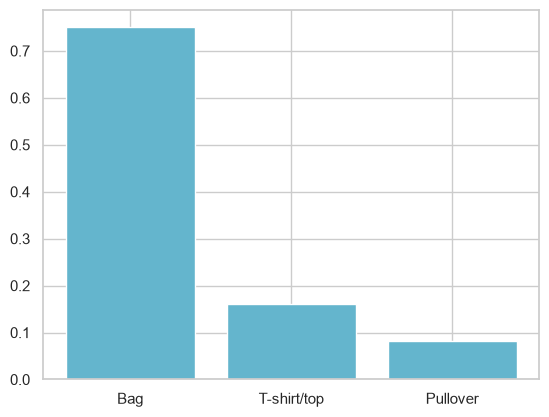

In [57]:
# show the probability of the top-3 predictions in a bar chart
top3_names = [class_names[i] for i in top[:3]]

plt.bar(top3_names, pred[0][top[:3]], color='c')
plt.show()

- External photos only work after matching the training format: crop to the item, square frame, 28×28, dark background
- A raw product photo (white backdrop, non-square) reads as a bright frame around a dark blob — the model takes it for a Bag; correcting polarity and framing is what makes the prediction sensible

Note: the `data_augmentation` layers are only active during training, so prediction results are deterministic and stable.

## 9. Summary: Pros, Cons & Real-World Examples

**Pros:**
- Learns complex non-linear patterns automatically.
- State of the art on unstructured data (images, audio, text).
- Highly flexible architecture choices.

**Cons:**
- Needs large amounts of data and compute.
- Many hyperparameters to tune.
- Prone to overfitting on small data.
- Low interpretability ('black box').

**Real-world examples:**
- Image recognition (classification, object detection, segmentation)
- Speech-to-text / audio processing
- Machine translation
- Large language models

**Guidelines checklist applied in this notebook:**
- ✔ Large dataset with complex patterns — Fashion MNIST (70k images)
- ✔ Data cleaning — no missing values; normalised to [0, 1]
- ✔ EDA — class balance check + label sanity-check via image samples
- ✔ Train/validation/test split — stratified split + early stopping on validation loss
- ✔ Augmentation — mild translation/flip to grow effective dataset size
- ✔ Model training — forward pass, backprop, Adam optimiser, tuned architecture/lr/batch/dropout
- ✔ Evaluation — Accuracy, Precision, Recall, F1, ROC-AUC, train/val loss curves
- ✔ Error analysis — confusion pairs, per-class error counts, confidence analysis, most-confident mistakes
- ✔ Error reduction — test-time augmentation and targeted fine-tuning (label smoothing + class weights)